In [2]:
import pandas as pd

df = pd.read_csv("../data/cell-count.csv")
df.shape

(10500, 15)

In [3]:
df.head()

,project,subject,condition,age,sex,treatment,response,sample,sample_type,time_from_treatment_start,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
0,prj1,sbj000,melanoma,57,M,miraclib,no,sample00000,PBMC,0,10908,24440,20491,13864,23511
1,prj1,sbj000,melanoma,57,M,miraclib,no,sample00001,PBMC,7,6777,19407,33459,18170,23011
2,prj1,sbj000,melanoma,57,M,miraclib,no,sample00002,PBMC,14,9794,22940,24274,17482,18332
3,prj1,sbj001,carcinoma,68,M,miraclib,yes,sample00003,PBMC,0,10081,20271,36157,14041,12610
4,prj1,sbj001,carcinoma,68,M,miraclib,yes,sample00004,PBMC,7,4372,33778,38293,16527,14933


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   project                    10500 non-null  str  
 1   subject                    10500 non-null  str  
 2   condition                  10500 non-null  str  
 3   age                        10500 non-null  int64
 4   sex                        10500 non-null  str  
 5   treatment                  10500 non-null  str  
 6   response                   9078 non-null   str  
 7   sample                     10500 non-null  str  
 8   sample_type                10500 non-null  str  
 9   time_from_treatment_start  10500 non-null  int64
 10  b_cell                     10500 non-null  int64
 11  cd8_t_cell                 10500 non-null  int64
 12  cd4_t_cell                 10500 non-null  int64
 13  nk_cell                    10500 non-null  int64
 14  monocyte                   10500 

In [6]:
df.isnull().sum()

project                         0
subject                         0
condition                       0
age                             0
sex                             0
treatment                       0
response                     1422
sample                          0
sample_type                     0
time_from_treatment_start       0
b_cell                          0
cd8_t_cell                      0
cd4_t_cell                      0
nk_cell                         0
monocyte                        0
dtype: int64

- Only `response` has NULLs (1422). All other columns are fully populated.

Compare the differences in cell population relative frequencies of melanoma patients receiving miraclib who respond (responders) versus those who do not (non-responders), with the overarching aim of predicting response to the treatment miraclib. Response information can be found in column "response", with value "yes" for responding and value "no" for non-responding. Please only include PBMC samples.

In [8]:
df["response_null"] = df["response"].isnull()
df.groupby(["condition", "treatment"])["response_null"].mean()

condition  treatment
carcinoma  miraclib     0.0
           phauximab    0.0
healthy    none         1.0
melanoma   miraclib     0.0
           phauximab    0.0
Name: response_null, dtype: float64

In [9]:
for col in ["condition", "treatment", "sample_type", "response"]:
    print(df[col].value_counts(dropna=False))
    print()

condition
melanoma     5175
carcinoma    3903
healthy      1422
Name: count, dtype: int64

treatment
miraclib     4695
phauximab    4383
none         1422
Name: count, dtype: int64

sample_type
PBMC    7500
WB      3000
Name: count, dtype: int64

response
yes    4611
no     4467
NaN    1422
Name: count, dtype: int64



In [11]:
df.groupby("subject").size().value_counts()

3500    3
Name: count, dtype: int64

### There are exactly 3 samples per subject.

In [12]:
# confirm subject count and check timepoint set per subject is exactly {0,7,14}, no dup/missing
print(df["subject"].nunique(), "subjects")
timepoint_sets = df.groupby("subject")["time_from_treatment_start"].apply(lambda s: tuple(sorted(s)))
timepoint_sets.value_counts()

3500 subjects


time_from_treatment_start
(0, 7, 14)    3500
Name: count, dtype: int64

- Confirmed rigorously: 3500 subjects, each with exactly timepoints (0, 7, 14) — no duplicates, no missing, no extra values. Clean repeated-measures structure (3 samples/subject).

In [13]:
pops = ["b_cell", "cd8_t_cell", "cd4_t_cell", "nk_cell", "monocyte"]
df.groupby("time_from_treatment_start")[pops].describe().T

time_from_treatment_start            0             7             14
b_cell     count            3500.000000   3500.000000   3500.000000
           mean             9987.177714   9895.265143   9858.447143
           std              3181.798204   3139.577007   3185.041775
           min              2153.000000   2292.000000   1835.000000
           25%              7695.750000   7610.250000   7596.750000
           50%              9695.500000   9549.000000   9541.000000
           75%             11855.750000  11814.750000  11838.500000
           max             24441.000000  27733.000000  23232.000000
cd8_t_cell count            3500.000000   3500.000000   3500.000000
           mean            25003.340000  25036.271143  24925.101429
           std              4790.583675   4674.556490   4747.171703
           min             11208.000000  11996.000000  11083.000000
           25%             21767.750000  21760.000000  21545.000000
           50%             24646.500000  24809.000000  24673.500000
           75%             27923.500000  28053.750000  27916.250000
           max             45045.000000  47259.000000  41647.000000
cd4_t_cell count            3500.000000   3500.000000   3500.000000
           mean            30270.975143  30214.855143  30688.897714
           std              5269.683542   5233.253566   5291.552090
           min             12959.000000  14552.000000  13999.000000
           25%             26729.750000  26560.250000  26989.500000
           50%             30005.000000  29941.500000  30472.000000
           75%             33578.500000  33667.250000  33903.750000
           max             57081.000000  51089.000000  52559.000000
nk_cell    count            3500.000000   3500.000000   3500.000000
           mean            14976.142286  15006.293714  14908.226286
           std              3816.531880   3873.827548   3832.588976
           min              5065.000000   4125.000000   4801.000000
           25%             12168.750000  12309.500000  12274.250000
           50%             14672.500000  14762.500000  14648.000000
           75%             17371.750000  17342.250000  17360.250000
           max             31887.000000  31859.000000  32720.000000
monocyte   count            3500.000000   3500.000000   3500.000000
           mean            20148.432571  20186.124857  19928.772857
           std              4368.102657   4384.600304   4420.414499
           min              6736.000000   6113.000000   7894.000000
           25%             17113.500000  17128.500000  16944.750000
           50%             19904.500000  19832.500000  19632.000000
           75%             22852.000000  22925.500000  22703.500000
           max             40535.000000  41647.000000  40986.000000

In [14]:
df[pops].std().sort_values(ascending=False)

cd4_t_cell    5268.629737
cd8_t_cell    4737.457276
monocyte      4392.141589
nk_cell       3840.911741
b_cell        3169.033950
dtype: float64

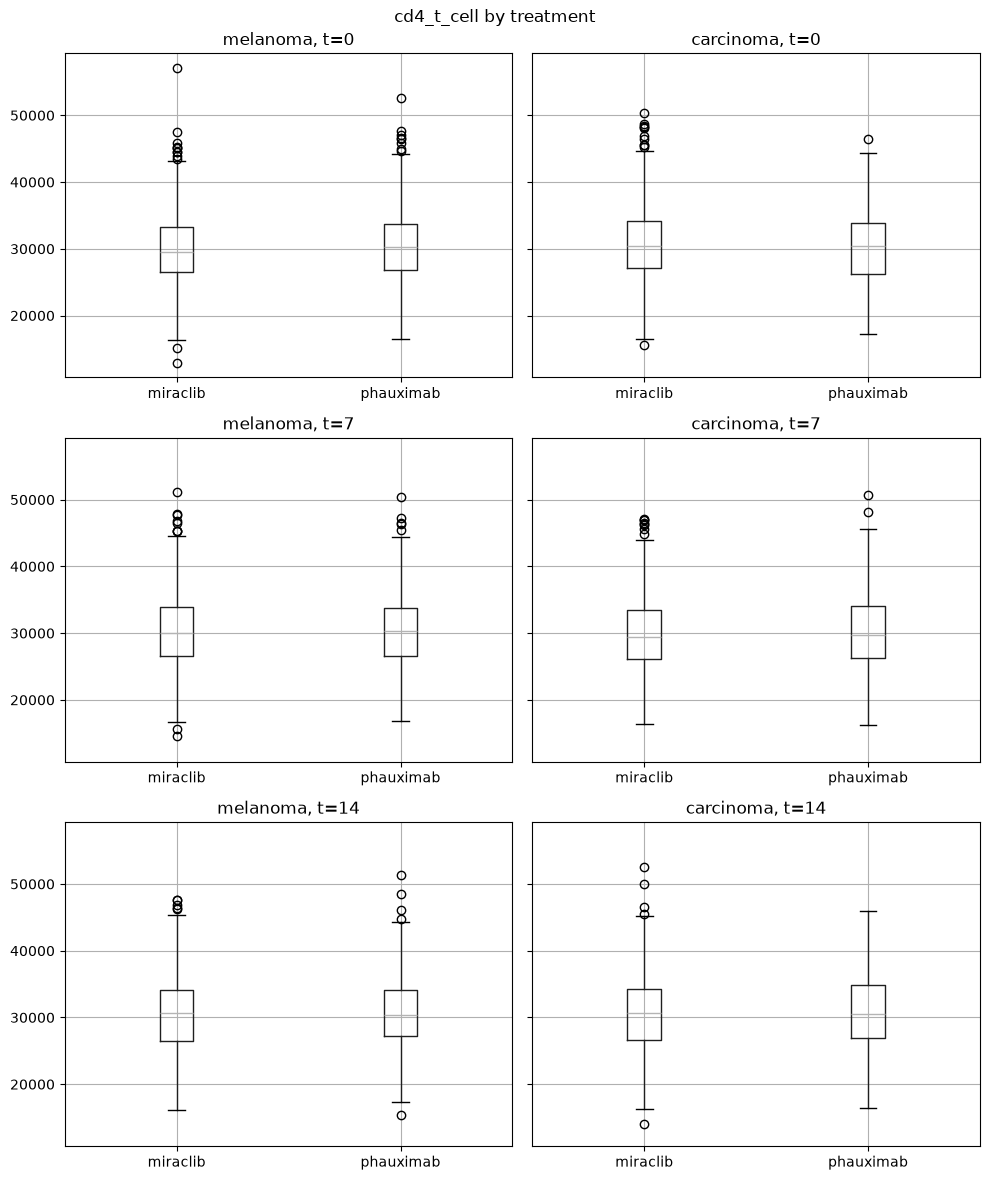

In [15]:
import matplotlib.pyplot as plt

y_col = "cd4_t_cell"  # largest std among the 5 populations
plot_df = df[df["condition"] != "healthy"]
times = [0, 7, 14]
conditions = ["melanoma", "carcinoma"]

fig, axes = plt.subplots(3, 2, figsize=(10, 12), sharey=True)
for i, t in enumerate(times):
    for j, cond in enumerate(conditions):
        ax = axes[i, j]
        sub = plot_df[(plot_df["time_from_treatment_start"] == t) & (plot_df["condition"] == cond)]
        sub.boxplot(column=y_col, by="treatment", ax=ax)
        ax.set_title(f"{cond}, t={t}")
        ax.set_xlabel("")
plt.suptitle(f"{y_col} by treatment")
plt.tight_layout()
plt.show()

### Decision: Part 3 timepoint handling
- Boxplot grid (cd4_t_cell, largest std) across t=0/7/14 x melanoma/carcinoma x treatment shows near-identical distributions — no obvious visual shift by time/treatment on raw counts alone.
- instruction.txt Part 3 does NOT mandate baseline-only (only Part 4 explicitly requires `time_from_treatment_start == 0`). Baseline-only is our statistical choice, not an instruction requirement.
- Decision: primary Part 3 output uses **baseline (t=0)** — avoids repeated-measures pseudoreplication, matches "predictive biomarker" framing. Implement the domain-layer comparison function with `time_from_treatment_start` as a parameter (default 0) so it can be re-run on t=7/14 subsets later without code changes.

In [16]:
part3 = df[
    (df["condition"] == "melanoma")
    & (df["treatment"] == "miraclib")
    & (df["sample_type"] == "PBMC")
    & (df["time_from_treatment_start"] == 0)
]
part3["response"].value_counts(dropna=False)

response
yes    331
no     325
Name: count, dtype: int64

- Part 3 baseline subset (melanoma + miraclib + PBMC + t=0): 656 samples = 331 responders (yes) + 325 non-responders (no). Matches expected count.

In [17]:
freq = part3[pops].div(part3[pops].sum(axis=1), axis=0) * 100
freq["response"] = part3["response"]
freq.groupby("response")[pops].median()

,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
response,,,,,
no,9.758175,24.601028,29.530535,14.890454,20.286002
yes,9.785035,24.395688,29.633822,14.997332,19.605580


- Median relative frequencies are close between responders/non-responders across all 5 populations; `monocyte` shows the largest gap (~20.3 vs ~19.6). No population shows an obvious large separation by eye — consistent with realistic biomarker signals being subtle (need proper stats + effect size, not just eyeballing).

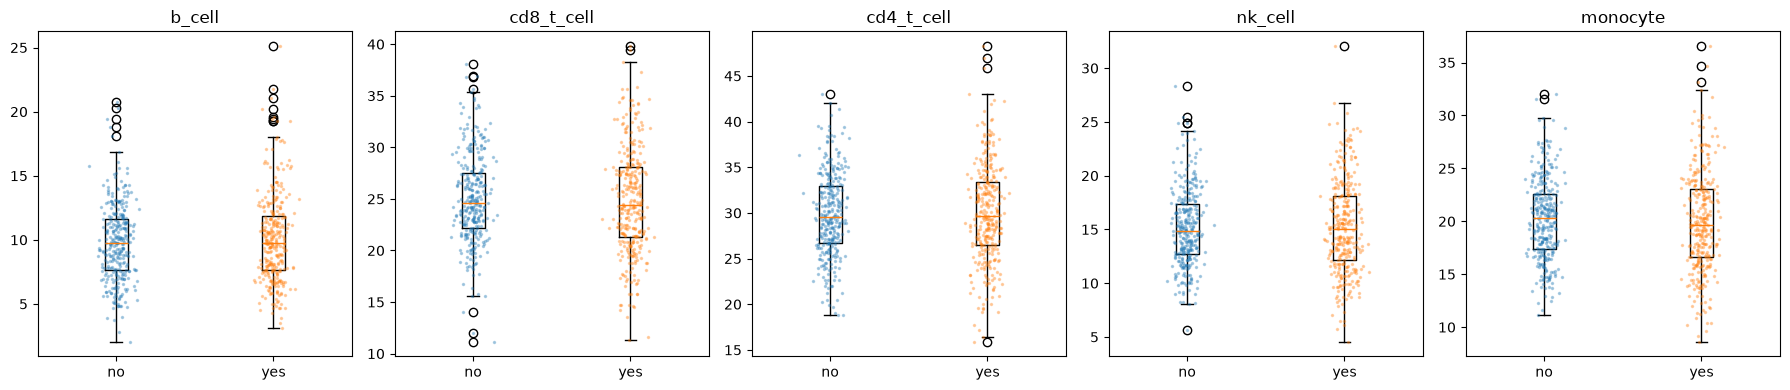

In [20]:
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=False)
for ax, pop in zip(axes, pops):
    data = [freq.loc[freq["response"] == r, pop] for r in ["no", "yes"]]
    ax.boxplot(data, tick_labels=["no", "yes"])
    for i, d in enumerate(data, start=1):
        x = np.random.normal(loc=float(i), scale=0.05, size=len(d))
        ax.plot(x, d, ".", alpha=0.3, markersize=3)
    ax.set_title(pop)
plt.tight_layout()
plt.show()

- Boxplot+jitter (responder vs non-responder, baseline, all 5 populations): heavy overlap in every population, no visually obvious separation. `cd8_t_cell` shows slightly wider spread / more high outliers in non-responders. Confirms need for formal stats (Mann-Whitney + effect size + BH correction) rather than eyeballing. Realistic, subtle biomarker signal.